In [ ]:
# SMOKE MODE: quick local check before full run
SMOKE_MODE = True
SMOKE_SAMPLE_FILES = 10000      # set 0 to disable file list slicing, use all files
SMOKE_TRAIN_SAMPLES = 50   # optional row cap after full build
SMOKE_VAL_SAMPLES = 20
SMOKE_TEST_SAMPLES = 20

EPOCHS = 2
FL_ROUND = 3

show_detailed_print = 1 # show detailed logs of the UART connection


# Project Machine Learning for IOTs
Author: Yingshuo Xi, Ali Jahangiri


# Federated Learning PC update summary

- Extract data to plot


# 1 Data Loading

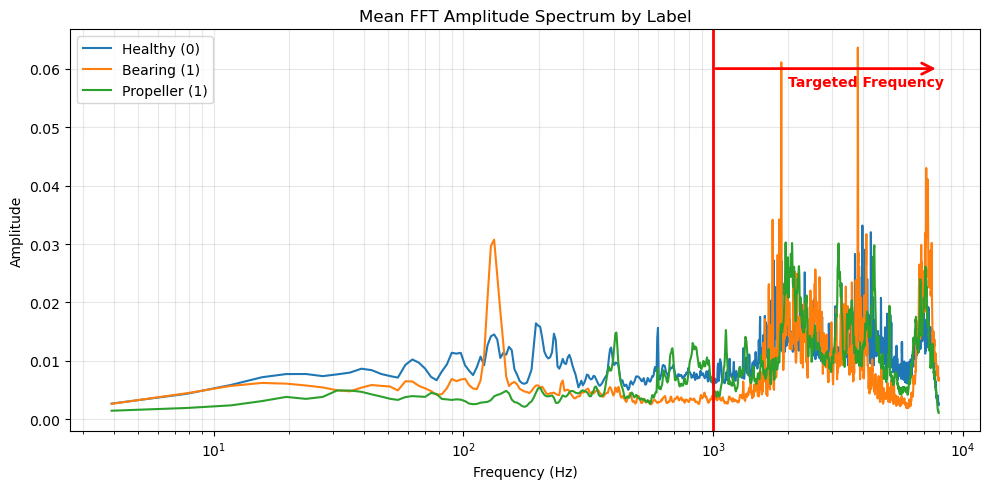

In [22]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

name = [ # Healthy
        # "../../Data/Healthy/M1/1400.wav",        # Not included due to different sampling rate
        "../../Data/Healthy/M1/1450.wav", "../../Data/Healthy/M1/1550.wav", "../../Data/Healthy/M1/1650.wav",
        "../../Data/Healthy/M1/1750.wav", "../../Data/Healthy/M1/1850.wav", "../../Data/Healthy/M1/1950.wav", "../../Data/Healthy/M1/2000.wav", 
        
        "../../Data/Healthy/M2/1400.wav", "../../Data/Healthy/M2/1450.wav", "../../Data/Healthy/M2/1550.wav", "../../Data/Healthy/M2/1650.wav",
        "../../Data/Healthy/M2/1750.wav", "../../Data/Healthy/M2/1850.wav", "../../Data/Healthy/M2/1950.wav", "../../Data/Healthy/M2/2000.wav", 

        "../../Data/Healthy/M3/1450.wav", "../../Data/Healthy/M3/1550.wav", "../../Data/Healthy/M3/1650.wav",
        "../../Data/Healthy/M3/1750.wav", "../../Data/Healthy/M3/1850.wav", "../../Data/Healthy/M3/1950.wav", 

        # Bearing
        "../../Data/Bearing/M4/1700.wav", "../../Data/Bearing/M4/1750.wav", "../../Data/Bearing/M4/1800.wav", "../../Data/Bearing/M4/1850.wav", 
        "../../Data/Bearing/M4/1900.wav", "../../Data/Bearing/M4/1950.wav", "../../Data/Bearing/M4/2000.wav",

        # Propeller
        "../../Data/Propeller/M1/1400.wav", "../../Data/Propeller/M1/1450.wav", "../../Data/Propeller/M1/1550.wav", "../../Data/Propeller/M1/1650.wav", 
        "../../Data/Propeller/M1/1750.wav", "../../Data/Propeller/M1/1850.wav",

        "../../Data/Propeller/M2/1400.wav", "../../Data/Propeller/M2/1450.wav", "../../Data/Propeller/M2/1550.wav", "../../Data/Propeller/M2/1650.wav", 
        "../../Data/Propeller/M2/1750.wav", "../../Data/Propeller/M2/1850.wav", "../../Data/Propeller/M2/1950.wav", "../../Data/Propeller/M2/2000.wav"
       ]
labels = [  # Healthy
            0, 0, 0,
            0, 0, 0, 0, 
            
            0, 0, 0, 0,
            0, 0, 0, 0, 
    
            0, 0, 0,
            0, 0, 0,

            # Bearing
            1, 1, 1, 1, 
            1, 1, 1,

            # Propeller
            2, 2, 2, 2,
            2, 2,
    
            2, 2, 2, 2,
            2, 2, 2, 2
           ]

# 0 = Train, 1 = Validation, 1 = Test, 2 = Not used
train_val_test_mark = [  # Healthy
            0, 1, 2,
            0, 3, 3, 3, 
            
            0, 1, 2, 0,
            0, 1, 2, 0, 
    
            0, 1, 2,
            0, 3, 3,

            # Bearing
            0, 1, 2, 0, 
            0, 1, 2,

            # Propeller
            0, 1, 2, 0,
            3, 3,
    
            0, 1, 2, 0,
            3, 3, 3, 3
           ]

def mean_amp_spectrum_by_segments(x, fs, n_fft=4096):
    x = x.astype(np.float64)
    x = x - np.mean(x)

    w = np.hanning(n_fft)

    # Segmentation
    n = len(x)
    if n < n_fft:
        x = np.pad(x, (0, n_fft - n))
        n = len(x)

    starts = np.arange(0, n - n_fft + 1, n_fft // 2)
    amps = []

    for s in starts:
        frame = x[s:s+n_fft] * w
        X = np.fft.rfft(frame, n=n_fft)

        # Amplitude Spectrum
        A = np.abs(X) / (np.sum(w) + 1e-12)
        amps.append(A)

    A_mean = np.mean(np.stack(amps, axis=0), axis=0)
    f = np.fft.rfftfreq(n_fft, d=1.0/fs)
    return f, A_mean

def plot_mean_fft_by_label(names, labels, n_fft=4096):
    spec_by_label = {0: [], 1: [], 2: []}
    f_ref = None
    fs_ref = None

    for path, lab in zip(names, labels):
        fs, data = wavfile.read(path)

        if data.ndim == 2:
            data = data.mean(axis=1)

        # Data Normalization
        eps = 1e-12
        data = data.astype(np.float64)
        data = (data - data.mean()) / (data.std() + eps)

        # Check the sampling rate
        if fs_ref is None:
            fs_ref = fs
        elif fs != fs_ref:
            raise ValueError(f"Sampling rate is difference")

        f, A_mean = mean_amp_spectrum_by_segments(data, fs, n_fft=n_fft)
        if f_ref is None:
            f_ref = f

        spec_by_label[int(lab)].append(A_mean)

    # Average by label
    A0 = np.mean(np.stack(spec_by_label[0], axis=0), axis=0) if len(spec_by_label[0]) else None
    A1 = np.mean(np.stack(spec_by_label[1], axis=0), axis=0) if len(spec_by_label[1]) else None
    A2 = np.mean(np.stack(spec_by_label[2], axis=0), axis=0) if len(spec_by_label[2]) else None

    plt.figure(figsize=(10, 5))
    if A0 is not None:
        plt.semilogx(f_ref[1:], A0[1:], label="Healthy (0)")
    if A1 is not None:
        plt.semilogx(f_ref[1:], A1[1:], label="Bearing (1)")
    if A2 is not None:
        plt.semilogx(f_ref[1:], A2[1:], label="Propeller (1)")

    plt.title("Mean FFT Amplitude Spectrum by Label")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    return fs

sampling_rate = plot_mean_fft_by_label(name, labels)
plt.axvline(x=1e3, color='red', linewidth=2)
plt.annotate('', xy=(8e3, 0.06), xytext=(1e3, 0.06), arrowprops=dict(arrowstyle='->', color='red', linewidth=2, mutation_scale=20))
plt.text(2e3, 0.057, "Targeted Frequency", color='red', fontsize=10, fontweight="bold")
plt.show()

In [23]:
import math

def min_samples_for_frequency(f0, sample_rate, K=5):
    L = K * sample_rate / f0
    return math.ceil(L)

f0 = 1000
K = 5

L = min_samples_for_frequency(f0, sampling_rate, K)
print(f"To capture enough cycles ({K}) of the frequency ({f0} Hz) based on the sampling rate ({sampling_rate} Hz), \033[1mthe minimal data points per sample: {L}\033[0m.")

To capture enough cycles (5) of the frequency (1000 Hz) based on the sampling rate (16000 Hz), the minimal data points per sample: 80.


In [24]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

segment_length = 80
downsampling_rate = 10

# helper to support board-specific class selection using complete labels
label_to_name = {0: 'healthy', 1: 'bearing', 2: 'propeller'}

labels_value = (np.array(labels) < 1).astype(int)

def build_dataset(name, labels, mark, target_mark, fault_class='bearing', healthy_half='first', mean_train=None, std_train=None):
    all_segments = []
    all_labels = []

    if fault_class not in ['bearing', 'propeller']:
        raise ValueError("fault_class must be either 'bearing' or 'propeller'.")

    fault_label = 1 if fault_class == 'bearing' else 2

    # Select candidate indices by phase (train/val/test) and class
    candidate_indices = [i for i in range(len(name)) if mark[i] == target_mark and labels[i] in (0, fault_label)]

    healthy_indices = [i for i in candidate_indices if labels[i] == 0]
    fault_indices = [i for i in candidate_indices if labels[i] == fault_label]

    # For training/validation, use half of healthy samples as requested
    if target_mark != 2:
        half = len(healthy_indices) // 2
        if healthy_half == 'first':
            healthy_indices = healthy_indices[:half]
        elif healthy_half == 'second':
            healthy_indices = healthy_indices[half:]
        elif healthy_half is None:
            pass
        else:
            raise ValueError("healthy_half must be 'first', 'second', or None")

    selected_indices = sorted(healthy_indices + fault_indices)

    if len(selected_indices) == 0:
        return np.empty((0, segment_length), dtype=np.float64), np.empty((0,), dtype=np.uint8), mean_train, std_train

    for i in selected_indices:
        sample_rate, data = wavfile.read(name[i])
        if len(data.shape) == 2:
            data = data.mean(axis=1)

        eps = 1e-12
        mean = data.mean()
        std = data.std()
        data = (data - mean) / (std + eps)

        num_segments = len(data) // segment_length
        data = data[:num_segments * segment_length]
        segments = data.reshape(num_segments, segment_length)

        label_binary = 0 if labels[i] == 0 else 1
        labels_segment = np.full(num_segments, label_binary, dtype=np.uint8)

        all_segments.append(segments)
        all_labels.append(labels_segment)

    all_segments = np.vstack(all_segments)
    all_labels = np.concatenate(all_labels)

    print("Before shuffle:", all_segments.shape, all_labels.shape)

    indices_perm = np.random.permutation(len(all_segments))
    all_segments = all_segments[indices_perm]
    all_labels = all_labels[indices_perm]

    print("After shuffle:", all_segments.shape, all_labels.shape)
    print(f"label(0) = {len(all_labels) - np.sum(all_labels)} ({(1 - np.sum(all_labels)/len(all_labels))*100:.2f}%), label(1) = {np.sum(all_labels)} ({(np.sum(all_labels)/len(all_labels))*100:.2f}%)")

    return all_segments, all_labels, mean_train, std_train


def build_stratified_global_test_set(names, labels, segment_length=80, test_ratio=0.2, random_state=42):
    """Build a representative global test set from healthy,bearing,propeller classes."""
    labels_arr = np.array(labels)
    np.random.seed(random_state)

    test_indices = []
    for cls in np.unique(labels_arr):
        idx_cls = np.where(labels_arr == cls)[0]
        n_cls = max(1, int(len(idx_cls) * test_ratio))
        selected = np.random.choice(idx_cls, size=n_cls, replace=False)
        test_indices.extend(selected)

    np.random.shuffle(test_indices)

    all_segments = []
    all_labels = []

    for i in test_indices:
        sample_rate, data = wavfile.read(names[i])
        if data.ndim == 2:
            data = data.mean(axis=1)

        eps = 1e-12
        mean = data.mean()
        std = data.std()
        data = (data - mean) / (std + eps)

        num_segments = len(data) // segment_length
        if num_segments == 0:
            continue

        data = data[:num_segments * segment_length]
        segments = data.reshape(num_segments, segment_length)

        class_label = 0 if labels[i] == 0 else 1
        labels_segment = np.full(num_segments, class_label, dtype=np.uint8)

        all_segments.append(segments)
        all_labels.append(labels_segment)

    if len(all_segments) == 0:
        return np.empty((0, segment_length), dtype=np.float64), np.empty((0,), dtype=np.uint8)

    all_segments = np.vstack(all_segments)
    all_labels = np.concatenate(all_labels)

    perm = np.random.permutation(len(all_segments))
    return all_segments[perm], all_labels[perm]



In [25]:
print("Total available samples:")

# COM16: healthy + bearing (healthy first half for train/val, full for test)
print("COM16 TRAIN: ")
train_X_com16, train_y_com16, mean_train, std_train = build_dataset(name, labels, train_val_test_mark, 0, fault_class='bearing', healthy_half='first')
print("COM16 VALIDATION: ")
val_X_com16, val_y_com16, _, _ = build_dataset(name, labels, train_val_test_mark, 1, fault_class='bearing', healthy_half='first', mean_train=mean_train, std_train=std_train)
print("COM16 TEST: ")
test_X_com16, test_y_com16, _, _ = build_dataset(name, labels, train_val_test_mark, 2, fault_class='bearing', healthy_half=None, mean_train=mean_train, std_train=std_train)

# COM21: healthy + propeller (healthy second half for train/val, full for test)
print("COM21 TRAIN: ")
train_X_com21, train_y_com21, _, _ = build_dataset(name, labels, train_val_test_mark, 0, fault_class='propeller', healthy_half='second')
print("COM21 VALIDATION: ")
val_X_com21, val_y_com21, _, _ = build_dataset(name, labels, train_val_test_mark, 1, fault_class='propeller', healthy_half='second', mean_train=mean_train, std_train=std_train)
print("COM21 TEST: ")
test_X_com21, test_y_com21, _, _ = build_dataset(name, labels, train_val_test_mark, 2, fault_class='propeller', healthy_half=None, mean_train=mean_train, std_train=std_train)

print(f"COM16 counts: train={len(train_X_com16)}, val={len(val_X_com16)}, test={len(test_X_com16)}")
print(f"COM21 counts: train={len(train_X_com21)}, val={len(val_X_com21)}, test={len(test_X_com21)}")

# Build a globally representative stratified test set drawn randomly from all 3 classes
print("Building global stratified test set from healthy/bearing/propeller...")
test_X_global, test_y_global = build_stratified_global_test_set(name, labels, segment_length=segment_length, test_ratio=0.2, random_state=123)
print(f"Global test set: total={len(test_X_global)}, class dist={np.bincount(test_y_global)}")

# Cap by SMOKE limits after full builds (all file inputs are processed)
if SMOKE_MODE:
    print("\nSMOKE MODE: Capping dataset sizes for quick testing...")
    train_X_com16, train_y_com16 = train_X_com16[:SMOKE_TRAIN_SAMPLES], train_y_com16[:SMOKE_TRAIN_SAMPLES]
    val_X_com16, val_y_com16 = val_X_com16[:SMOKE_VAL_SAMPLES], val_y_com16[:SMOKE_VAL_SAMPLES]
    test_X_com16, test_y_com16 = test_X_global[:SMOKE_TEST_SAMPLES], test_y_global[:SMOKE_TEST_SAMPLES]

    train_X_com21, train_y_com21 = train_X_com21[:SMOKE_TRAIN_SAMPLES], train_y_com21[:SMOKE_TRAIN_SAMPLES]
    val_X_com21, val_y_com21 = val_X_com21[:SMOKE_VAL_SAMPLES], val_y_com21[:SMOKE_VAL_SAMPLES]
    test_X_com21, test_y_com21 = test_X_global[:SMOKE_TEST_SAMPLES], test_y_global[:SMOKE_TEST_SAMPLES]


Total available samples:
COM16 TRAIN: 
Before shuffle: (14404, 80) (14404,)
After shuffle: (14404, 80) (14404,)
label(0) = 8173 (56.74%), label(1) = 6231 (43.26%)
COM16 VALIDATION: 
Before shuffle: (8263, 80) (8263,)
After shuffle: (8263, 80) (8263,)
label(0) = 4115 (49.80%), label(1) = 4148 (50.20%)
COM16 TEST: 
Before shuffle: (12306, 80) (12306,)
After shuffle: (12306, 80) (12306,)
label(0) = 8206 (66.68%), label(1) = 4100 (33.32%)
COM21 TRAIN: 
Before shuffle: (16421, 80) (16421,)
After shuffle: (16421, 80) (16421,)
label(0) = 8227 (50.10%), label(1) = 8194 (49.90%)
COM21 VALIDATION: 
Before shuffle: (8209, 80) (8209,)
After shuffle: (8209, 80) (8209,)
label(0) = 4121 (50.20%), label(1) = 4088 (49.80%)
COM21 TEST: 
Before shuffle: (12292, 80) (12292,)
After shuffle: (12292, 80) (12292,)
label(0) = 8206 (66.76%), label(1) = 4086 (33.24%)
COM16 counts: train=14404, val=8263, test=12306
COM21 counts: train=16421, val=8209, test=12292
Building global stratified test set from healthy/be

# 3 PC & STM32

Here is the code for PC and STM32. You can first start either PC or STM32. The order does not matter.

**The code below is universal for both Backpropagation and Forward-Forward.**

You can view detailed messages by setting the parameter **show_detaied_print** to 1.

Switches of STM32:
- SW1: End Python code, Set STM32 to Idle

In [26]:
import serial
import struct
import time

CODE_START_OF_FRAME_0 = b"\xAA"
CODE_START_OF_FRAME_1 = b"\x55"
CODE_START_OF_FRAME = CODE_START_OF_FRAME_0 + CODE_START_OF_FRAME_1

CODE_REQUEST_DATA = 0x01
CODE_DATA = 0x02
CODE_ACKNOWLEDGEMENT = 0x03
CODE_FINISH = 0x04
CODE_END = 0x05
CODE_RESULTS_TRAIN = 0x06
CODE_REQUEST_VAL = 0x07
CODE_VAL_ACC = 0x08
CODE_REQUEST_TEST = 0x09
CODE_TEST_PRED = 0x0A

CODE_CTRL_START = 0x0B
CODE_CTRL_STOP = 0x0C
CODE_CTRL_PAUSE = 0x0D
CODE_CTRL_RESUME = 0x0E
CODE_CTRL_MODE = 0x0F
CODE_CTRL_EPOCHS = 0x10
CODE_CTRL_STATUS = 0x11
CODE_REQUEST_WEIGHTS = 0x12
CODE_WEIGHTS = 0x13
CODE_SET_WEIGHTS = 0x14
CODE_FED_ROLE = 0x15
CODE_FED_UPDATE = 0x16
CODE_FED_COMMIT = 0x17
CODE_FED_BROADCAST = 0x18

NN_H1 = 40
NN_H2 = 20
NN_IN = 80

In [27]:
class Board:
    def __init__(self, port, baud, show_detailed_print=1, log_prefix=None, log_path='Result_BP_FL.txt', log_interval=5000):
        self.port = port
        self.baud = baud
        self.show_detailed_print = show_detailed_print
        self.log_prefix = log_prefix or f"[{port}]"
        self.log_path = log_path

        # Initialize (clear) log file once when board is constructed
        with open(self.log_path, 'w', encoding='utf-8') as f:
            f.write('')

        self.correct_count = 0
        self.epochs_completed = 0

        self.window_correct = 0
        self.window_total = 0
        self.window_loss_sum = 0.0
        self.log_interval = log_interval
        self.test_predictions = []

        self.weights_by_epoch = {}
        self.current_epoch = 0
        self.current_fl_round = 1
        self.train_acc_by_epoch = {}
        self.val_acc_by_epoch = {}

    def _log(self, message):
        if self.show_detailed_print:
            print(f"{self.log_prefix} {message}")

    def append_log(self, line):
        with open(self.log_path, 'a', encoding='utf-8') as f:
            f.write(line + '\n')

    def crc_check(self, data: bytes) -> int:
        crc = 0xFFFF
        for d in data:
            crc ^= (d << 8)
            for _ in range(8):
                if crc & 0x8000:
                    crc = ((crc << 1) ^ 0x1021) & 0xFFFF
                else:
                    crc = (crc << 1) & 0xFFFF
        return crc

    def pack_frame(self, data_type: int, message_sequence: int, data: bytes) -> bytes:
        message_sequence &= 0xFFFF
        length = len(data) & 0xFFFF
        message_bytes = struct.pack("<BHH", data_type, message_sequence, length) + data
        crc = self.crc_check(message_bytes)
        crc_bytes = struct.pack("<H", crc)
        return CODE_START_OF_FRAME + message_bytes + crc_bytes

    def pack_control_frame(self, control_type: int, payload: bytes = b"") -> bytes:
        length = len(payload) & 0xFFFF
        message_bytes = struct.pack("<BHH", control_type, 0, length) + payload
        crc = self.crc_check(message_bytes)
        return CODE_START_OF_FRAME + message_bytes + struct.pack("<H", crc)

    def send_control(self, ser, control_type: int, payload: bytes = b""):
        ser.write(self.pack_control_frame(control_type, payload))
        self._log(f"Sent control frame: type={hex(control_type)} len={len(payload)}")

    def send_weights(self, ser, weights_dict, epoch):
        # Serialize weights in nn_state_export order: W1,b1,W2,b2,W3,b3
        payload = b"".join([
            weights_dict['W1'].astype(np.float32).tobytes(),
            weights_dict['b1'].astype(np.float32).tobytes(),
            weights_dict['W2'].astype(np.float32).tobytes(),
            weights_dict['b2'].astype(np.float32).tobytes(),
            weights_dict['W3'].astype(np.float32).tobytes(),
            np.array([weights_dict['b3']], dtype=np.float32).tobytes(),
        ])

        if len(payload) != (NN_H1*NN_IN + NN_H1 + NN_H2*NN_H1 + NN_H2 + NN_H2 + 1) * 4:
            raise ValueError(f"Serialized weight size incorrect: {len(payload)}")

        ser.write(self.pack_frame(CODE_SET_WEIGHTS, epoch, payload))
        self._log(f"Sent SET_WEIGHTS frame epoch={epoch} len={len(payload)}")

    def send_fed_role(self, ser, role):
        # role: 'server' or 'client'
        value = 1 if role == 'server' else 0
        ser.write(self.pack_frame(CODE_FED_ROLE, 0, bytes([value])))
        self._log(f"Sent FED_ROLE={role} frame")

    def send_fed_update(self, ser, weights_dict):
        payload = b"".join([
            weights_dict['W1'].astype(np.float32).tobytes(),
            weights_dict['b1'].astype(np.float32).tobytes(),
            weights_dict['W2'].astype(np.float32).tobytes(),
            weights_dict['b2'].astype(np.float32).tobytes(),
            weights_dict['W3'].astype(np.float32).tobytes(),
            np.array([weights_dict['b3']], dtype=np.float32).tobytes(),
        ])
        ser.write(self.pack_frame(CODE_FED_UPDATE, 0, payload))
        self._log(f"Sent FED_UPDATE frame len={len(payload)}")

    def send_fed_commit(self, ser):
        ser.write(self.pack_frame(CODE_FED_COMMIT, 0, b""))
        self._log("Sent FED_COMMIT frame")

    def send_fed_broadcast(self, ser, weights_dict):
        payload = b"".join([
            weights_dict['W1'].astype(np.float32).tobytes(),
            weights_dict['b1'].astype(np.float32).tobytes(),
            weights_dict['W2'].astype(np.float32).tobytes(),
            weights_dict['b2'].astype(np.float32).tobytes(),
            weights_dict['W3'].astype(np.float32).tobytes(),
            np.array([weights_dict['b3']], dtype=np.float32).tobytes(),
        ])
        ser.write(self.pack_frame(CODE_FED_BROADCAST, 0, payload))
        self._log(f"Sent FED_BROADCAST frame len={len(payload)}")

    def read_n_bytes(self, ser, n: int):
        buf_all = bytearray()
        while len(buf_all) < n:
            buf = ser.read(n - len(buf_all))
            if not buf:
                return None
            buf_all += buf
        return bytes(buf_all)

    def read_frame(self, ser):
        while True:
            start_of_frame_0 = ser.read(1)
            if not start_of_frame_0:
                return None
            if start_of_frame_0 == CODE_START_OF_FRAME_0:
                start_of_frame_1 = ser.read(1)
                if not start_of_frame_1:
                    return None
                if start_of_frame_1 == CODE_START_OF_FRAME_1:
                    break

        header = self.read_n_bytes(ser, 1 + 2 + 2)
        if header is None:
            return None

        data_type = header[0]
        message_sequence, length = struct.unpack("<HH", header[1:])

        data = self.read_n_bytes(ser, length)
        if data is None:
            return None

        crc_bytes = self.read_n_bytes(ser, 2)
        if crc_bytes is None:
            return None

        crc_recv = struct.unpack("<H", crc_bytes)[0]
        body = struct.pack("<BHH", data_type, message_sequence, length) + data

        if self.crc_check(body) != crc_recv:
            self._log("CRC mismatch, frame dropped")
            return None

        return data_type, message_sequence, data

    def handle_results_frame(self, seq, data):
        if len(data) < 9:
            self._log(f"Invalid RESULTS frame at seq={seq}, len={len(data)}")
            return

        loss = struct.unpack("<f", data[0:4])[0]
        probability = struct.unpack("<f", data[4:8])[0]
        correct = int(data[8])

        self.correct_count += correct
        self.window_correct += correct
        self.window_total += 1
        self.window_loss_sum += loss

        self._log(
            f"Results decoded: seq={seq}, "
            f"loss={loss:.6f}, probability={probability:.6f}, correct={correct}"
        )

        if self.window_total >= self.log_interval:
            window_acc = self.window_correct / self.window_total if self.window_total > 0 else 0.0
            window_loss_avg = self.window_loss_sum / self.window_total if self.window_total > 0 else 0.0
            line = f"{self.log_prefix} WinAcc({self.window_total}): {window_acc:.4f} | WinAvgLoss({self.window_total}): {window_loss_avg:.6f}"
            print(line)
            self.append_log(line)
            self.window_correct = 0
            self.window_total = 0
            self.window_loss_sum = 0.0

    def handle_test_pred_frame(self, seq, data, test_y):
        if len(data) < 5:
            self._log(f"Invalid TEST_PRED frame at seq={seq}, len={len(data)}")
            return

        probability = struct.unpack("<f", data[0:4])[0]
        pred = int(data[4])

        y_true = int(test_y[seq]) if seq < len(test_y) else None

        item = {
            "seq": int(seq),
            "y_true": y_true,
            "probability": float(probability),
            "pred": pred,
        }
        self.test_predictions.append(item)

        self._log(
            f"TEST_PRED decoded: seq={seq}, "
            f"probability={probability:.6f}, pred={pred}, y_true={y_true}"
        )


    def handle_weights_frame(self, seq, data):
        expected_size = (NN_H1 * NN_IN) + NN_H1 + (NN_H2 * NN_H1) + NN_H2 + NN_H2 + 1
        expected_size *= 4  # Convert floats to bytes
        if len(data) < expected_size:
            self._log(f"Invalid WEIGHTS frame at seq={seq}, len={len(data)}, expected={expected_size}")
            return

        p = 0
        W1 = np.frombuffer(data[p:p+NN_H1*NN_IN*4], dtype=np.float32).reshape(NN_H1, NN_IN)
        p += NN_H1 * NN_IN * 4
        b1 = np.frombuffer(data[p:p+NN_H1*4], dtype=np.float32)
        p += NN_H1 * 4
        W2 = np.frombuffer(data[p:p+NN_H2*NN_H1*4], dtype=np.float32).reshape(NN_H2, NN_H1)
        p += NN_H2 * NN_H1 * 4
        b2 = np.frombuffer(data[p:p+NN_H2*4], dtype=np.float32)
        p += NN_H2 * 4
        W3 = np.frombuffer(data[p:p+NN_H2*4], dtype=np.float32)
        p += NN_H2 * 4
        b3 = np.frombuffer(data[p:p+4], dtype=np.float32)[0]

        epoch = int(seq)
        self.weights_by_epoch[epoch] = {
            "W1": W1, "b1": b1,
            "W2": W2, "b2": b2,
            "W3": W3, "b3": b3
        }

        filename = f"weights_{self.port}_round{self.current_fl_round:02d}_epoch{epoch:02d}.npz"
        np.savez(filename, W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)
        self._log(f"Saved weights for epoch {epoch} to {filename}")

    def request_weights(self, ser):
        self.send_control(ser, CODE_REQUEST_WEIGHTS)
        self._log("Requested weights from STM32")

    def save_accuracy_log(self, filepath="accuracy_log.csv"):
        import csv
        with open(filepath, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(["port", "epoch", "train_acc", "val_acc"])
            epochs = sorted(set(list(self.train_acc_by_epoch.keys()) + list(self.val_acc_by_epoch.keys())))
            for epoch in epochs:
                train_acc = self.train_acc_by_epoch.get(epoch, "")
                val_acc = self.val_acc_by_epoch.get(epoch, "")
                writer.writerow([self.port, epoch, train_acc, val_acc])
        self._log(f"Saved accuracy log to {filepath}")
    def send_dataset(self, train_X, train_y, val_X, val_y, test_X, test_y, epochs=2, mode=0, idle_timeout=15):
        self.test_predictions = []
        self.correct_count = 0
        self.window_correct = 0
        self.window_total = 0
        self.window_loss_sum = 0.0

        train_done = False
        val_done = False
        test_done = False

        segment_length = train_X.shape[1]

        if val_X.shape[1] != segment_length:
            raise ValueError("train_X and val_X feature dimensions do not match")

        if test_X.shape[1] != segment_length:
            raise ValueError("train_X and test_X feature dimensions do not match")

        with serial.Serial(self.port, self.baud, timeout=0.2) as ser:
            time.sleep(1)
            ser.reset_input_buffer()
            ser.reset_output_buffer()

            self.send_control(ser, CODE_CTRL_EPOCHS, struct.pack("<H", epochs))
            self.send_control(ser, CODE_CTRL_MODE, bytes([mode]))
            self.send_control(ser, CODE_CTRL_START)

            self._log("Ready. Waiting for STM32 requests...")
            self.append_log(f"{self.log_prefix} Ready. Waiting for STM32 requests...")
            last_report_time = time.time()

            while True:
                frame = self.read_frame(ser)
                now = time.time()

                if frame is None:
                    if now - last_report_time > 2:
                        if train_done and val_done and test_done:
                            msg = "All phases done + idle timeout, closing connection."
                            self._log(msg)
                            self.append_log(f"{self.log_prefix} {msg}")
                            self.send_control(ser, CODE_CTRL_STOP)
                            self.test_predictions.sort(key=lambda x: x["seq"])

                            self.save_accuracy_log()
                            return self.test_predictions

                        if now - last_report_time > idle_timeout:
                            msg = "Idle timeout reached with incomplete phases; closing connection."
                            self._log(msg)
                            self.append_log(f"{self.log_prefix} {msg}")
                            self.send_control(ser, CODE_CTRL_STOP)
                            self.test_predictions.sort(key=lambda x: x["seq"])
                            return self.test_predictions

                        self._log("Still waiting for requests...")
                        last_report_time = now
                    continue

                last_report_time = now
                data_type, seq, data = frame
                self._log(f"Main-loop got frame: type={hex(data_type)} seq={seq} len={len(data)}")

                if data_type == CODE_END:
                    msg = "Received END from STM32. Exit."
                    self._log(msg)
                    self.append_log(f"{self.log_prefix} {msg}")
                    self.test_predictions.sort(key=lambda x: x["seq"])
                    return self.test_predictions

                if data_type == CODE_ACKNOWLEDGEMENT:
                    status = data[0] if len(data) >= 1 else 0
                    if status != 0:
                        print(f"{self.log_prefix} ACK error: seq={seq}, status={status}")
                    else:
                        self._log(f"ACK ok: seq={seq}")
                    continue

                if data_type == CODE_RESULTS_TRAIN:
                    self.handle_results_frame(seq, data)
                    continue

                if data_type == CODE_TEST_PRED:
                    self.handle_test_pred_frame(seq, data, test_y)
                    continue

                if data_type == CODE_WEIGHTS:
                    self.handle_weights_frame(seq, data)
                    continue

                if data_type == CODE_VAL_ACC:
                    if len(data) >= 4:
                        acc = struct.unpack("<f", data[:4])[0]
                        log_line = f"{self.log_prefix} STM32 inference accuracy = {acc:.6f}"
                        print(log_line)
                        self.append_log(log_line)

                    self.window_correct = 0
                    self.window_total = 0
                    self.window_loss_sum = 0.0
                    self.correct_count = 0

                    self.val_acc_by_epoch[self.epochs_completed] = acc
                    continue

                if data_type == CODE_CTRL_STATUS:
                    if len(data) >= 9:
                        mode = data[0]
                        running = bool(data[1])
                        paused = bool(data[2])
                        runtime_epochs = data[3] | (data[4] << 8)
                        current_epoch = data[5] | (data[6] << 8) | (data[7] << 16) | (data[8] << 24)
                        print(
                            f"{self.log_prefix} STATUS: mode={mode}, running={running}, paused={paused}, "
                            f"epochs={runtime_epochs}, current_epoch={current_epoch}"
                        )
                    else:
                        self._log(f"Invalid STATUS frame at seq={seq}, len={len(data)}")
                    continue

                if data_type == CODE_REQUEST_DATA:
                    if seq >= train_X.shape[0]:
                        ser.write(self.pack_frame(CODE_FINISH, seq, b""))
                        train_done = True
                        msg = f"{self.log_prefix} Training data finished at seq={seq}, sent CODE_FINISH"
                        self._log(msg)
                        self.append_log(msg)

                        self.epochs_completed += 1
                        train_acc = self.correct_count / train_X.shape[0] if train_X.shape[0] > 0 else 0.0
                        self.train_acc_by_epoch[self.epochs_completed] = train_acc
                        print(f"{self.log_prefix} Training accuracy (epoch {self.epochs_completed}): {train_acc:.6f}")
                        if train_done and val_done and test_done:
                            self._log("All phases done after training completion.")
                            self.send_control(ser, CODE_CTRL_STOP)
                            self.test_predictions.sort(key=lambda x: x["seq"])
                            return self.test_predictions
                        continue

                    data_row = train_X[seq]
                    if len(data_row) != segment_length:
                        raise ValueError(
                            f"train sample {seq} length is {len(data_row)}, expected {segment_length}"
                        )

                    payload = struct.pack(
                        f"<B{segment_length}f",
                        int(train_y[seq]),
                        *data_row.tolist()
                    )

                    ser.write(self.pack_frame(CODE_DATA, seq, payload))
                    self._log(f"Sent TRAIN DATA seq={seq}")
                    continue

                if data_type == CODE_REQUEST_VAL:
                    if seq >= val_X.shape[0]:
                        ser.write(self.pack_frame(CODE_FINISH, seq, b""))
                        val_done = True
                        msg = f"{self.log_prefix} Inference data finished at seq={seq}, sent CODE_FINISH"
                        self._log(msg)
                        self.append_log(msg)
                        if train_done and val_done and test_done:
                            self._log("All phases done after validation completion.")
                            self.send_control(ser, CODE_CTRL_STOP)
                            self.test_predictions.sort(key=lambda x: x["seq"])
                            return self.test_predictions
                        continue

                    data_row = val_X[seq]
                    if len(data_row) != segment_length:
                        raise ValueError(
                            f"val sample {seq} length is {len(data_row)}, expected {segment_length}"
                        )

                    payload = struct.pack(
                        f"<B{segment_length}f",
                        int(val_y[seq]),
                        *data_row.tolist()
                    )

                    ser.write(self.pack_frame(CODE_DATA, seq, payload))
                    self._log(f"Sent INFER DATA seq={seq}")
                    continue

                if data_type == CODE_REQUEST_TEST:
                    if seq >= test_X.shape[0]:
                        ser.write(self.pack_frame(CODE_FINISH, seq, b""))
                        test_done = True

                        # compute test accuracy for this round only if within planned FL_ROUND count
                        if self.test_predictions and self.current_fl_round <= FL_ROUND:
                            y_true = [p['y_true'] for p in self.test_predictions if p['y_true'] is not None]
                            y_pred = [p['pred'] for p in self.test_predictions if p['y_true'] is not None]
                            if y_true:
                                test_acc = sum(1 for a, b in zip(y_true, y_pred) if a == b) / len(y_true)
                                tmsg = f"{self.log_prefix} FedRound {self.current_fl_round} TestAcc = {test_acc:.4f}"
                                self._log(tmsg)
                                self.append_log(tmsg)

                        msg = f"{self.log_prefix} Test data finished at seq={seq}, sent CODE_FINISH"
                        self._log(msg)
                        self.append_log(msg)

                        if train_done and val_done and test_done:
                            self._log("All phases done after test completion.")
                            self.send_control(ser, CODE_CTRL_STOP)
                            self.test_predictions.sort(key=lambda x: x["seq"])
                            if self.current_fl_round < FL_ROUND:
                                self.current_fl_round += 1
                            return self.test_predictions
                        continue

                    data_row = test_X[seq]
                    if len(data_row) != segment_length:
                        raise ValueError(
                            f"test sample {seq} length is {len(data_row)}, expected {segment_length}"
                        )

                    payload = struct.pack(
                        f"<B{segment_length}f",
                        int(test_y[seq]),
                        *data_row.tolist()
                    )

                    ser.write(self.pack_frame(CODE_DATA, seq, payload))
                    self._log(f"Sent TEST DATA seq={seq}")
                    continue

                self._log(f"Unexpected frame type: {hex(data_type)} seq={seq} len={len(data)}")

In [28]:
import threading

clients = {
    'COM16': Board('COM16', 209700, show_detailed_print, log_interval=1),
    'COM21': Board('COM21', 209700, show_detailed_print, log_interval=1),
}

results = {}


def runner(port, client, train_X, train_y, val_X, val_y, test_X, test_y, epochs=None):
    if epochs is None:
        epochs = EPOCHS

    try:
        results[port] = client.send_dataset(train_X, train_y, val_X, val_y, test_X, test_y, epochs=epochs)
    except Exception as exc:
        print(f"[{port}] thread exception: {exc}")
        results[port] = None

threads = []
# COM16 thread
thread_com16 = threading.Thread(
    target=runner,
    args=("COM16", clients["COM16"], train_X_com16, train_y_com16, val_X_com16, val_y_com16, test_X_com16, test_y_com16),
    daemon=False,
)
threads.append(thread_com16)
thread_com16.start()

# COM21 thread
thread_com21 = threading.Thread(
    target=runner,
    args=("COM21", clients["COM21"], train_X_com21, train_y_com21, val_X_com21, val_y_com21, test_X_com21, test_y_com21),
    daemon=False,
)
threads.append(thread_com21)
thread_com21.start()

for t in threads:
    t.join()

print("Parallel data transfer complete")
for port, r in results.items():
    if r is None:
        print(f"{port} failed or returned no data")
    else:
        print(f"{port} got {len(r)} test predictions")

with open('Result_BP_FL.txt', 'a', encoding='utf-8') as f:
    f.write('--- Federated run summary ---\n')
    for port, r in results.items():
        if r is None:
            f.write(f"{port} failed or returned no data\n")
        else:
            f.write(f"{port} got {len(r)} test predictions\n")

# Optional access
test_results_com16 = results.get('COM16')
test_results_com21 = results.get('COM21')

[COM21] Sent control frame: type=0x10 len=2
[COM16] Sent control frame: type=0x10 len=2
[COM21] Sent control frame: type=0xf len=1
[COM16] Sent control frame: type=0xf len=1
[COM21] Sent control frame: type=0xb len=0
[COM21] Ready. Waiting for STM32 requests...
[COM16] Sent control frame: type=0xb len=0
[COM16] Ready. Waiting for STM32 requests...
[COM21] Main-loop got frame: type=0x1 seq=0 len=0
[COM16] Main-loop got frame: type=0x1 seq=0 len=0
[COM21] Sent TRAIN DATA seq=0
[COM16] Sent TRAIN DATA seq=0
[COM16] Main-loop got frame: type=0x3 seq=0 len=1
[COM16] ACK ok: seq=0
[COM21] Main-loop got frame: type=0x6 seq=0 len=9
[COM21] Results decoded: seq=0, loss=0.476236, probability=0.371667, correct=1
[COM21] WinAcc(1): 1.0000 | WinAvgLoss(1): 0.476236
[COM21] Main-loop got frame: type=0x1 seq=0 len=0
[COM16] Main-loop got frame: type=0x6 seq=1 len=9
[COM16] Results decoded: seq=1, loss=1.239317, probability=0.310241, correct=0
[COM16] WinAcc(1): 0.0000 | WinAvgLoss(1): 1.239317
[COM16

In [29]:
print(f"Global test set: total={len(test_X_global)}, class dist={np.bincount(test_y_global)}")
print(f"Global test set: total={len(test_X_com16)}, class dist={np.bincount(test_y_com16)}")
print(f"Global test set: total={len(test_X_com21)}, class dist={np.bincount(test_y_com21)}")

Global test set: total=14359, class dist=[8194 6165]
Global test set: total=40, class dist=[26 14]
Global test set: total=40, class dist=[26 14]


In [30]:
# 4) Federated averaging on PC (no firmware changes)
import numpy as np

# Ensure both boards produced weights_by_epoch
common_epochs = sorted(
    set(clients['COM16'].weights_by_epoch.keys()) &
    set(clients['COM21'].weights_by_epoch.keys())
)

if not common_epochs:
    raise RuntimeError('No common epochs available for FedAvg. Check weight collection.')


def federated_average_weights(clients, epoch):
    """Return federated average weights dict for given epoch."""
    keys = ['W1','b1','W2','b2','W3','b3']

    all_client_layers = []
    for port, client in clients.items():
        w = client.weights_by_epoch.get(epoch)
        if w is None:
            print(f"WARNING: {port} has no weights for epoch {epoch}")
            continue
        all_client_layers.append(w)

    if not all_client_layers:
        raise ValueError(f"No available weights for epoch {epoch}")

    avg = {}
    for k in keys:
        layer_stack = np.stack([c[k] for c in all_client_layers], axis=0)
        avg[k] = np.mean(layer_stack, axis=0)

    return avg


federated_weights_by_epoch = {}
for epoch in common_epochs:
    avg = federated_average_weights(clients, epoch)
    federated_weights_by_epoch[epoch] = avg
    print(f"FedAvg computed for epoch {epoch}")

# Optional: save averaged weights to disk
for epoch, w in federated_weights_by_epoch.items():
    fout = f"weights_fedavg_prefl_epoch{epoch}.npz"
    np.savez(fout, **w)
    print(f"Saved {fout}")

# Optional: reuse averaged weights within client objects for local tracking
for epoch, avg in federated_weights_by_epoch.items():
    for client in clients.values():
        client.weights_by_epoch[epoch] = avg

print('Federated averaging complete.')


FedAvg computed for epoch 1
FedAvg computed for epoch 2
Saved weights_fedavg_prefl_epoch1.npz
Saved weights_fedavg_prefl_epoch2.npz
Federated averaging complete.


In [31]:
# 5) Upload averaged weights to device and verify via re-request

def send_weights_to_device(client, epoch, weights):
    payload = b"".join([
        weights['W1'].astype(np.float32).tobytes(),
        weights['b1'].astype(np.float32).tobytes(),
        weights['W2'].astype(np.float32).tobytes(),
        weights['b2'].astype(np.float32).tobytes(),
        weights['W3'].astype(np.float32).tobytes(),
        np.array([weights['b3']], dtype=np.float32).tobytes(),
    ])

    expected = ((NN_H1 * NN_IN) + NN_H1 + (NN_H2 * NN_H1) + NN_H2 + NN_H2 + 1) * 4
    if len(payload) != expected:
        raise ValueError(f"Payload size {len(payload)} != expected {expected}")

    with serial.Serial(client.port, client.baud, timeout=0.5) as ser:
        ser.reset_input_buffer(); ser.reset_output_buffer()
        ser.write(client.pack_frame(CODE_SET_WEIGHTS, epoch, payload))
        client._log(f"Sent SET_WEIGHTS epoch={epoch} payload={len(payload)}")

        deadline = time.time() + 5.0
        while time.time() < deadline:
            frame = client.read_frame(ser)
            if frame is None:
                continue
            t, seq, data = frame
            if t == CODE_ACKNOWLEDGEMENT:
                status = data[0] if len(data) else 1
                client._log(f"SET_WEIGHTS ack status={status}")
                return status == 0
            if t == CODE_CTRL_STATUS:
                client._log("Received status after SET_WEIGHTS")
                return True
        raise RuntimeError("No response after SET_WEIGHTS")


def request_and_verify_weights(client, epoch, expected):
    with serial.Serial(client.port, client.baud, timeout=0.5) as ser:
        ser.reset_input_buffer(); ser.reset_output_buffer()
        client.send_control(ser, CODE_REQUEST_WEIGHTS)

        deadline = time.time() + 8.0
        while time.time() < deadline:
            frame = client.read_frame(ser)
            if frame is None:
                continue
            t, seq, data = frame
            if t == CODE_WEIGHTS:
                client.handle_weights_frame(seq, data)
                got = client.weights_by_epoch.get(epoch)
                if got is None:
                    print(f"{client.port}: got weights with seq={seq} but no epoch")
                    return False

                ok = True
                for k in ['W1','b1','W2','b2','W3','b3']:
                    if not np.allclose(got[k], expected[k], atol=1e-6):
                        print(f"{client.port}: mismatch {k} norm={np.linalg.norm(got[k]-expected[k])}")
                        ok = False
                print(f"{client.port} verify {'PASSED' if ok else 'FAILED'}")
                return ok

        raise RuntimeError('Timeout waiting for WEIGHTS')


for epoch, avg_weights in federated_weights_by_epoch.items():
    print(f"=== Epoch {epoch} ===")
    for port, client in clients.items():
        try:
            ok_set = send_weights_to_device(client, epoch, avg_weights)
            print(f"{port}: set_weights => {ok_set}")
        except Exception as e:
            print(f"{port}: set_weights failed: {e}")
            continue

        try:
            ok_verify = request_and_verify_weights(client, epoch, avg_weights)
            print(f"{port}: verify => {ok_verify}")
        except Exception as e:
            print(f"{port}: verify failed: {e}")


=== Epoch 1 ===
[COM16] Sent SET_WEIGHTS epoch=1 payload=16324
[COM16] Received status after SET_WEIGHTS
COM16: set_weights => True
[COM16] Sent control frame: type=0x12 len=0
[COM16] Saved weights for epoch 2 to weights_COM16_round02_epoch02.npz
COM16 verify PASSED
COM16: verify => True
[COM21] Sent SET_WEIGHTS epoch=1 payload=16324
[COM21] Received status after SET_WEIGHTS
COM21: set_weights => True
[COM21] Sent control frame: type=0x12 len=0
[COM21] Saved weights for epoch 2 to weights_COM21_round02_epoch02.npz
COM21 verify PASSED
COM21: verify => True
=== Epoch 2 ===
[COM16] Sent SET_WEIGHTS epoch=2 payload=16324
[COM16] Received status after SET_WEIGHTS
COM16: set_weights => True
[COM16] Sent control frame: type=0x12 len=0
[COM16] Saved weights for epoch 2 to weights_COM16_round02_epoch02.npz
COM16 verify PASSED
COM16: verify => True
[COM21] Sent SET_WEIGHTS epoch=2 payload=16324
[COM21] Received status after SET_WEIGHTS
COM21: set_weights => True
[COM21] Sent control frame: type=

In [32]:
# 4) Federated learning orchestration on PC
import numpy as np
import threading

def federated_average_weights(clients, epoch):
    keys = ['W1','b1','W2','b2','W3','b3']
    all_client_layers = []
    for port, client in clients.items():
        w = client.weights_by_epoch.get(epoch)
        if w is None:
            print(f'WARNING: {port} has no weights for epoch {epoch}')
            continue
        all_client_layers.append(w)

    if not all_client_layers:
        raise ValueError(f'No available weights for epoch {epoch}')

    avg = {}
    for k in keys:
        layer_stack = np.stack([c[k] for c in all_client_layers], axis=0)
        avg[k] = np.mean(layer_stack, axis=0)

    return avg

def run_clients_training(clients, local_epochs):
    training_results = {}
    threads = []

    def runner(port, client, train_X, train_y, val_X, val_y, test_X, test_y):
        try:
            training_results[port] = client.send_dataset(train_X, train_y, val_X, val_y, test_X, test_y, epochs=local_epochs)
        except Exception as exc:
            print(f'[{port}] training exception: {exc}')
            training_results[port] = None

    mapping = {
        'COM16': (train_X_com16, train_y_com16, val_X_com16, val_y_com16, test_X_com16, test_y_com16),
        'COM21': (train_X_com21, train_y_com21, val_X_com21, val_y_com21, test_X_com21, test_y_com21),
    }

    for port, client in clients.items():
        if port not in mapping:
            raise ValueError(f'No dataset mapping for {port}')
        train_X, train_y, val_X, val_y, test_X, test_y = mapping[port]
        thread = threading.Thread(target=runner, args=(port, client, train_X, train_y, val_X, val_y, test_X, test_y), daemon=False)
        threads.append(thread)
        thread.start()

    for t in threads:
        t.join()

    return training_results

def send_weights_to_device(client, epoch, weights):
    payload = b''.join([
        weights['W1'].astype(np.float32).tobytes(),
        weights['b1'].astype(np.float32).tobytes(),
        weights['W2'].astype(np.float32).tobytes(),
        weights['b2'].astype(np.float32).tobytes(),
        weights['W3'].astype(np.float32).tobytes(),
        np.array([weights['b3']], dtype=np.float32).tobytes(),
    ])

    expected = ((NN_H1 * NN_IN) + NN_H1 + (NN_H2 * NN_H1) + NN_H2 + NN_H2 + 1) * 4
    if len(payload) != expected:
        raise ValueError(f'Payload size {len(payload)} != expected {expected}')

    with serial.Serial(client.port, client.baud, timeout=0.5) as ser:
        ser.reset_input_buffer(); ser.reset_output_buffer()
        ser.write(client.pack_frame(CODE_SET_WEIGHTS, epoch, payload))
        client._log(f'Sent SET_WEIGHTS epoch={epoch} payload={len(payload)}')

        deadline = time.time() + 5.0
        while time.time() < deadline:
            frame = client.read_frame(ser)
            if frame is None:
                continue
            t, seq, data = frame
            if t == CODE_ACKNOWLEDGEMENT:
                status = data[0] if len(data) else 1
                client._log(f'SET_WEIGHTS ack status={status}')
                return status == 0
            if t == CODE_CTRL_STATUS:
                client._log('Received status after SET_WEIGHTS')
                return True
        raise RuntimeError('No response after SET_WEIGHTS')

def request_and_verify_weights(client, epoch, expected):
    with serial.Serial(client.port, client.baud, timeout=0.5) as ser:
        ser.reset_input_buffer(); ser.reset_output_buffer()
        client.send_control(ser, CODE_REQUEST_WEIGHTS)

        deadline = time.time() + 8.0
        while time.time() < deadline:
            frame = client.read_frame(ser)
            if frame is None:
                continue
            t, seq, data = frame
            if t == CODE_WEIGHTS:
                client.handle_weights_frame(seq, data)
                got = client.weights_by_epoch.get(epoch)
                if got is None:
                    print(f'{client.port}: got weights with seq={seq} but no epoch')
                    return False

                ok = True
                for k in ['W1','b1','W2','b2','W3','b3']:
                    if not np.allclose(got[k], expected[k], atol=1e-6):
                        print(f'{client.port}: mismatch {k} norm={np.linalg.norm(got[k]-expected[k])}')
                        ok = False
                status_txt = 'PASSED' if ok else 'FAILED'
                print(f'{client.port} verify {status_txt}')
                return ok

        raise RuntimeError('Timeout waiting for WEIGHTS')

def perform_federated_learning(clients, local_epochs, fl_rounds):
    for fl_round in range(fl_rounds):
        round_id = fl_round + 1
        print(f'===== FL Round {round_id}/{fl_rounds} =====')

        # inform boards which federated round is active (for filename metadata)
        for client in clients.values():
            client.current_fl_round = round_id

        run_clients_training(clients, local_epochs)

        common_epochs = sorted(
            set(clients['COM16'].weights_by_epoch.keys()) &
            set(clients['COM21'].weights_by_epoch.keys())
        )

        if not common_epochs:
            raise RuntimeError('No common epochs available for federated averaging.')

        epoch = max(common_epochs)
        print(f'Using epoch {epoch} for FedAvg at round {round_id}')

        avg_weights = federated_average_weights(clients, epoch)
        fout = f'weights_round{round_id:02d}_fedavg.npz'
        np.savez(fout, **avg_weights)
        print(f'Saved {fout}')

        for port, client in clients.items():
            print(f'---- {port} apply federated weights (round {round_id}, epoch {epoch})')
            try:
                ok_set = send_weights_to_device(client, epoch, avg_weights)
                print(f'{port}: set_weights => {ok_set}')
            except Exception as e:
                print(f'{port}: set_weights failed: {e}')
                continue

            try:
                ok_verify = request_and_verify_weights(client, epoch, avg_weights)
                print(f'{port}: verify => {ok_verify}')
            except Exception as e:
                print(f'{port}: verify failed: {e}')

            client.weights_by_epoch[epoch] = avg_weights

    print('Federated training complete.')

# Override client training routine to use global test split on both devices

def run_clients_training_global_test(clients, local_epochs):
    training_results = {}
    threads = []

    def runner(port, client, train_X, train_y, val_X, val_y, test_X, test_y):
        try:
            training_results[port] = client.send_dataset(train_X, train_y, val_X, val_y, test_X, test_y, epochs=local_epochs)
        except Exception as exc:
            print(f'[{port}] training exception: {exc}')
            training_results[port] = None

    # override
    if SMOKE_MODE:
        mapping = {
            'COM16': (train_X_com16, train_y_com16, val_X_com16, val_y_com16, test_X_com16, test_y_com16),
            'COM21': (train_X_com21, train_y_com21, val_X_com21, val_y_com21, test_X_com21, test_y_com21),
        }
    else:
        mapping = {
            'COM16': (train_X_com16, train_y_com16, val_X_com16, val_y_com16, test_X_global, test_y_global),
            'COM21': (train_X_com21, train_y_com21, val_X_com21, val_y_com21, test_X_global, test_y_global),
        }

    for port, client in clients.items():
        if port not in mapping:
            raise ValueError(f'No dataset mapping for {port}')
        train_X, train_y, val_X, val_y, test_X, test_y = mapping[port]
        thread = threading.Thread(target=runner, args=(port, client, train_X, train_y, val_X, val_y, test_X, test_y), daemon=False)
        threads.append(thread)
        thread.start()

    for t in threads:
        t.join()

    return training_results

# Rebind the original name for perform_federated_learning usage
run_clients_training = run_clients_training_global_test

perform_federated_learning(clients, EPOCHS, FL_ROUND)


===== FL Round 1/6 =====
[COM16] Sent control frame: type=0x10 len=2
[COM16] Sent control frame: type=0xf len=1
[COM21] Sent control frame: type=0x10 len=2
[COM16] Sent control frame: type=0xb len=0
[COM16] Ready. Waiting for STM32 requests...
[COM21] Sent control frame: type=0xf len=1
[COM21] Sent control frame: type=0xb len=0
[COM21] Ready. Waiting for STM32 requests...
[COM16] Main-loop got frame: type=0x1 seq=0 len=0
[COM21] Main-loop got frame: type=0x1 seq=0 len=0
[COM16] Sent TRAIN DATA seq=0
[COM21] Sent TRAIN DATA seq=0
[COM16] Main-loop got frame: type=0x3 seq=0 len=1
[COM16] ACK ok: seq=0
[COM21] Main-loop got frame: type=0x6 seq=0 len=9
[COM21] Results decoded: seq=0, loss=0.395315, probability=0.320933, correct=1
[COM21] WinAcc(1): 1.0000 | WinAvgLoss(1): 0.395315
[COM16] Main-loop got frame: type=0x6 seq=1 len=9
[COM16] Results decoded: seq=1, loss=1.266155, probability=0.301338, correct=0
[COM16] WinAcc(1): 0.0000 | WinAvgLoss(1): 1.266155
[COM21] Main-loop got frame: ty

In [33]:
# Check the received data (for each board)
for board, test_results in [("COM16", test_results_com16), ("COM21", test_results_com21)]:

    seqs = [d["seq"] for d in test_results]
    print(f"{board} first seq samples:", seqs[:20])

    print(f"{board} len =", len(seqs))
    print(f"{board} unique len =", len(set(seqs)))
    print(f"{board} duplicates =", sorted([x for x in set(seqs) if seqs.count(x) > 1]))
    missing = [i for i in range(min(seqs), max(seqs)+1) if i not in set(seqs)]
    print(f"{board} missing =", missing)
    print()

COM16 first seq samples: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
COM16 len = 40
COM16 unique len = 40
COM16 duplicates = []
COM16 missing = []

COM21 first seq samples: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
COM21 len = 40
COM21 unique len = 40
COM21 duplicates = []
COM21 missing = []



=== COM16 ===
Accuracy: 0.6750
F1 score: 0.4800
Confusion Matrix:
[[21  5]
 [ 8  6]]


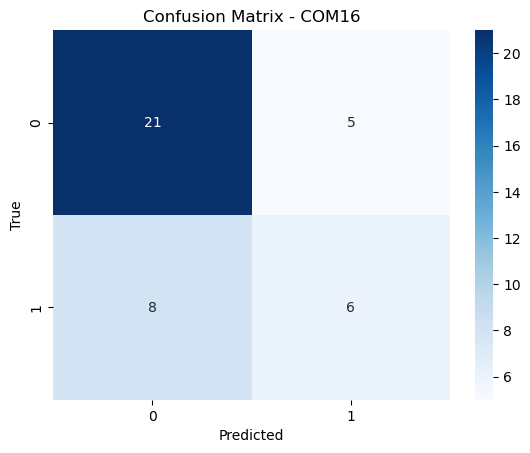

AUC: 0.8407


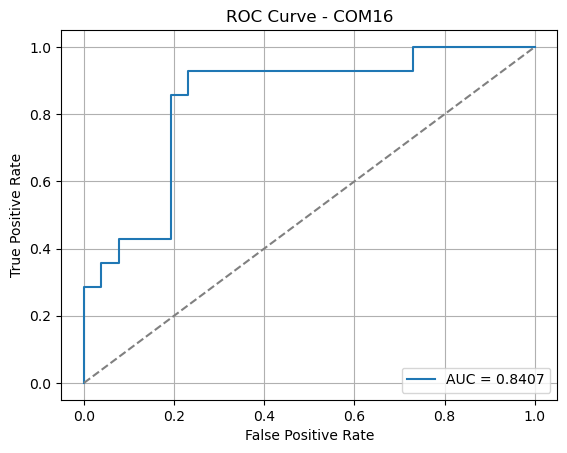

=== COM21 ===
Accuracy: 0.7500
F1 score: 0.6429
Confusion Matrix:
[[21  5]
 [ 5  9]]


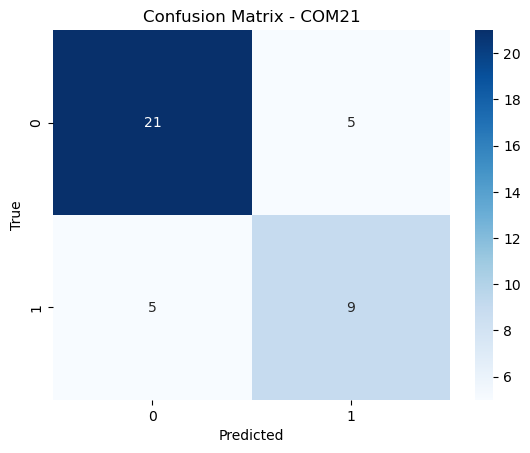

AUC: 0.8379


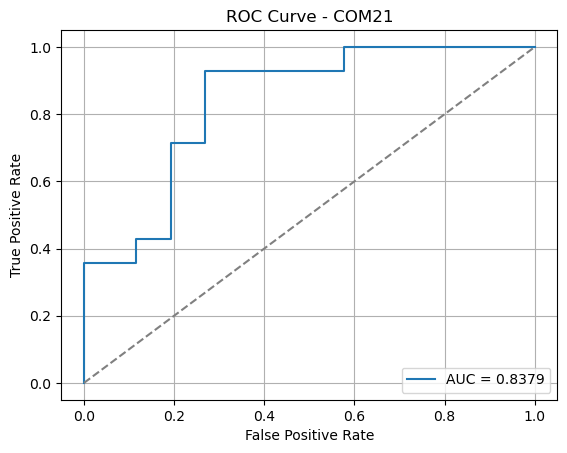

In [34]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

for board, data in [("COM16", test_results_com16), ("COM21", test_results_com21)]:
    if data is None or len(data) == 0:
        print(f"{board}: no test results available")
        continue

    filtered = [
        d for d in data
        if d["y_true"] in [0, 1] and d["pred"] in [0, 1]
    ]

    if len(filtered) == 0:
        print(f"{board}: no valid binary labels after filtering")
        continue

    y_true = np.array([d["y_true"] for d in filtered])
    y_pred = np.array([d["pred"] for d in filtered])
    y_prob = np.array([d["probability"] for d in filtered])

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"=== {board} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 score: {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}")

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[0, 1], yticklabels=[0, 1])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix - {board}")
    plt.show()

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    print(f"AUC: {roc_auc:.4f}")

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {board}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()